# **Artificial Neural Network**

Training Neural Network...
Epoch 0, Loss: 0.6375, Accuracy: 0.8213
Epoch 100, Loss: 0.0139, Accuracy: 0.9975
Epoch 200, Loss: 0.0113, Accuracy: 0.9962
Epoch 300, Loss: 0.0112, Accuracy: 0.9962
Epoch 400, Loss: 0.0110, Accuracy: 0.9962
Epoch 500, Loss: 0.0058, Accuracy: 0.9975
Epoch 600, Loss: 0.0044, Accuracy: 0.9988
Epoch 700, Loss: 0.0037, Accuracy: 0.9988
Epoch 800, Loss: 0.0030, Accuracy: 0.9988
Epoch 900, Loss: 0.0028, Accuracy: 0.9988

Final Results:
Training Accuracy: 0.9988
Test Accuracy: 0.9800


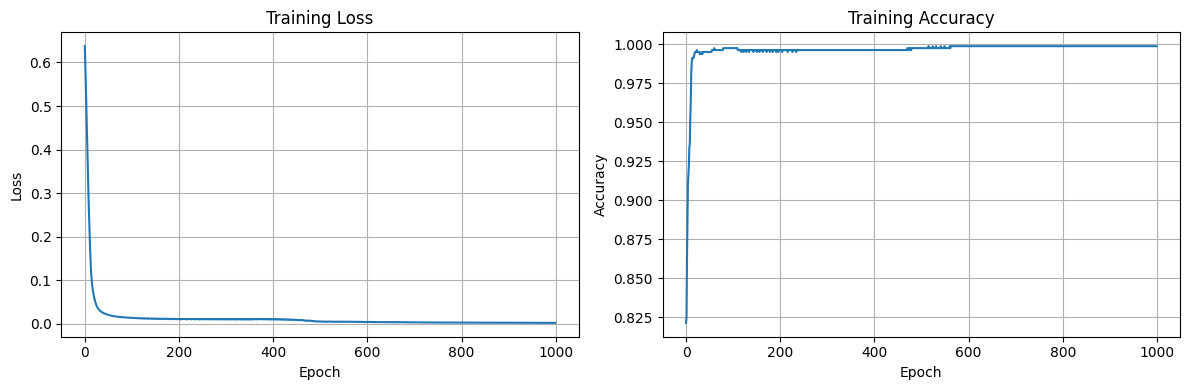

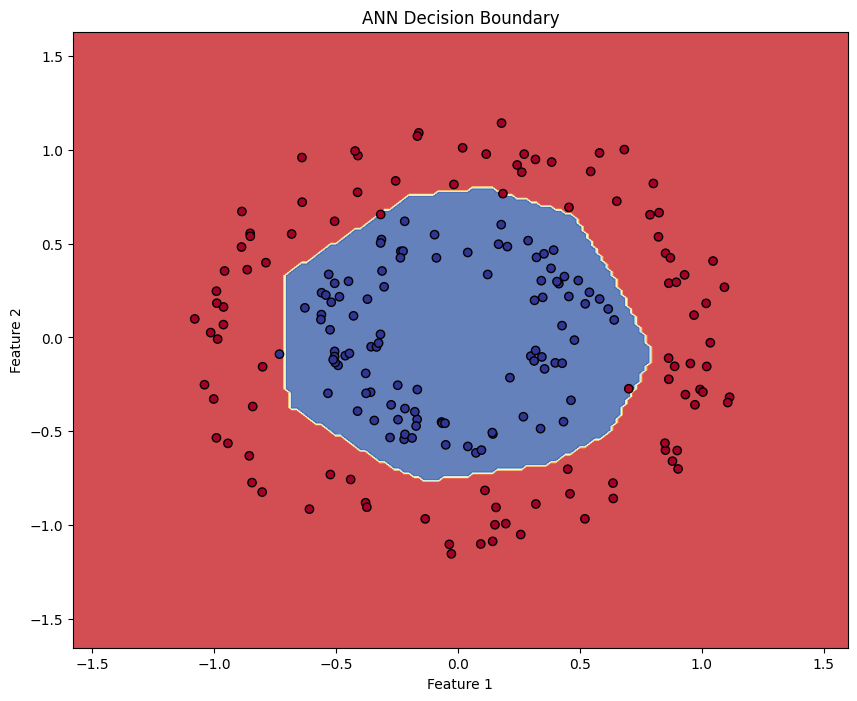

In [7]:
import numpy as np
import matplotlib.pyplot as plt

class NeuralNetwork:
    def __init__(self, layers, learning_rate=0.01):
        """
        Initialize neural network
        layers: list of neurons in each layer [input, hidden1, hidden2, ..., output]
        """
        self.layers = layers
        self.learning_rate = learning_rate
        self.weights = []
        self.biases = []
        
        # Initialize weights and biases
        for i in range(len(layers) - 1):
            # He initialization for ReLU
            w = np.random.randn(layers[i], layers[i+1]) * np.sqrt(2.0 / layers[i])
            b = np.zeros((1, layers[i+1]))
            self.weights.append(w)
            self.biases.append(b)
    
    def sigmoid(self, x):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-np.clip(x, -250, 250)))
    
    def sigmoid_derivative(self, x):
        """Derivative of sigmoid"""
        return x * (1 - x)
    
    def relu(self, x):
        """ReLU activation function"""
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        """Derivative of ReLU"""
        return (x > 0).astype(float)
    
    def softmax(self, x):
        """Softmax activation for output layer"""
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def forward(self, X, activation='relu'):
        """
        Forward propagation
        Returns activations and cache for backprop
        """
        self.cache = [X]
        current_input = X
        
        # Hidden layers
        for i in range(len(self.weights) - 1):
            z = np.dot(current_input, self.weights[i]) + self.biases[i]
            if activation == 'relu':
                a = self.relu(z)
            else:
                a = self.sigmoid(z)
            self.cache.append(a)
            current_input = a
        
        # Output layer
        z_output = np.dot(current_input, self.weights[-1]) + self.biases[-1]
        a_output = self.softmax(z_output)
        self.cache.append(a_output)
        
        return a_output
    
    def backward(self, y, output):
        """
        Backward propagation
        y: true labels (one-hot encoded)
        output: predicted output from forward pass
        """
        m = y.shape[0]  # number of samples
        gradients_w = []
        gradients_b = []
        
        # Output layer gradient (using cross-entropy with softmax)
        dz = output - y
        
        # Backpropagate through layers
        for i in range(len(self.weights) - 1, -1, -1):
            dw = (1/m) * np.dot(self.cache[i].T, dz)
            db = (1/m) * np.sum(dz, axis=0, keepdims=True)
            gradients_w.insert(0, dw)
            gradients_b.insert(0, db)
            
            # Propagate to previous layer if not at input
            if i > 0:
                da = np.dot(dz, self.weights[i].T)
                # Apply activation derivative
                if i > 0:  # Hidden layers used ReLU
                    dz = da * (self.cache[i] > 0).astype(float)
        
        return gradients_w, gradients_b
    
    def update_parameters(self, gradients_w, gradients_b):
        """Update weights and biases using gradients"""
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * gradients_w[i]
            self.biases[i] -= self.learning_rate * gradients_b[i]
    
    def train(self, X, y, epochs=1000, batch_size=32, verbose=True):
        """
        Train the neural network
        X: input features
        y: labels (0 or 1)
        """
        # Convert labels to one-hot encoding
        y_one_hot = np.zeros((y.shape[0], self.layers[-1]))
        y_one_hot[np.arange(y.shape[0]), y.astype(int)] = 1
        
        losses = []
        accuracies = []
        
        for epoch in range(epochs):
            # Mini-batch training
            for i in range(0, X.shape[0], batch_size):
                X_batch = X[i:i+batch_size]
                y_batch = y_one_hot[i:i+batch_size]
                
                # Forward pass
                output = self.forward(X_batch)
                
                # Backward pass
                gradients_w, gradients_b = self.backward(y_batch, output)
                
                # Update parameters
                self.update_parameters(gradients_w, gradients_b)
            
            # Calculate loss and accuracy
            output = self.forward(X)
            loss = -np.mean(np.sum(y_one_hot * np.log(output + 1e-8), axis=1))
            predictions = np.argmax(output, axis=1)
            accuracy = np.mean(predictions == y)
            
            losses.append(loss)
            accuracies.append(accuracy)
            
            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")
        
        return losses, accuracies
    
    def predict(self, X):
        """Make predictions"""
        output = self.forward(X)
        return np.argmax(output, axis=1)
    
    def evaluate(self, X, y):
        """Evaluate model accuracy"""
        predictions = self.predict(X)
        return np.mean(predictions == y)

# Example: Binary classification on synthetic data
if __name__ == "__main__":
    # Generate synthetic dataset
    np.random.seed(42)
    n_samples = 1000
    
    # Create two concentric circles
    from sklearn.datasets import make_circles
    X, y = make_circles(n_samples=n_samples, noise=0.1, factor=0.5, random_state=42)
    
    # Split into train/test
    split = int(0.8 * n_samples)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # Create and train ANN
    # Architecture: 2 inputs -> 8 hidden (ReLU) -> 4 hidden (ReLU) -> 2 outputs (Softmax)
    nn = NeuralNetwork(layers=[2, 8, 4, 2], learning_rate=0.1)
    
    print("Training Neural Network...")
    losses, accuracies = nn.train(X_train, y_train, epochs=1000, batch_size=32)
    
    # Evaluate
    train_acc = nn.evaluate(X_train, y_train)
    test_acc = nn.evaluate(X_test, y_test)
    
    print(f"\nFinal Results:")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    
    # Plot loss and accuracy curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(losses)
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)
    
    ax2.plot(accuracies)
    ax2.set_title('Training Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Visualize decision boundary
    def plot_decision_boundary(model, X, y):
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                             np.arange(y_min, y_max, 0.02))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        plt.figure(figsize=(10, 8))
        plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='black')
        plt.title('ANN Decision Boundary')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.show()
    
    plot_decision_boundary(nn, X_test, y_test)